In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [3]:
df = load_iris()
df

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
# Convert training features into DataFrame (important for hierarchical clustering analysis/visualization)
x = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
# train test split
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train , y_test = train_test_split(x , y , train_size=0.75 , random_state= 42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
# apply PCA
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=2)

In [18]:
x_train_pca_scaled = pca.fit_transform(x_train_scaled)
x_test_pca_scaled = pca.transform(x_test_scaled)

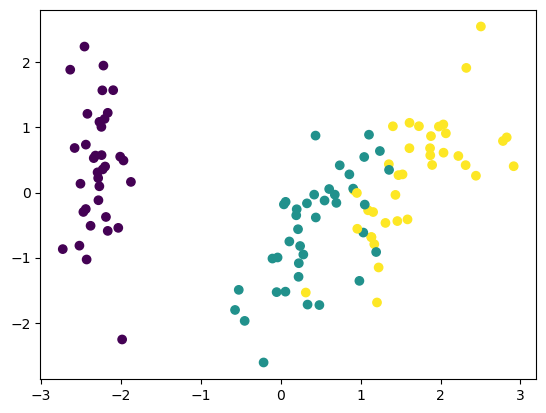

In [20]:
plt.scatter(x_train_pca_scaled[: ,0] , x_train_pca_scaled[: , 1] , c=y_train)

Text(0, 0.5, 'Eucledian Distance')

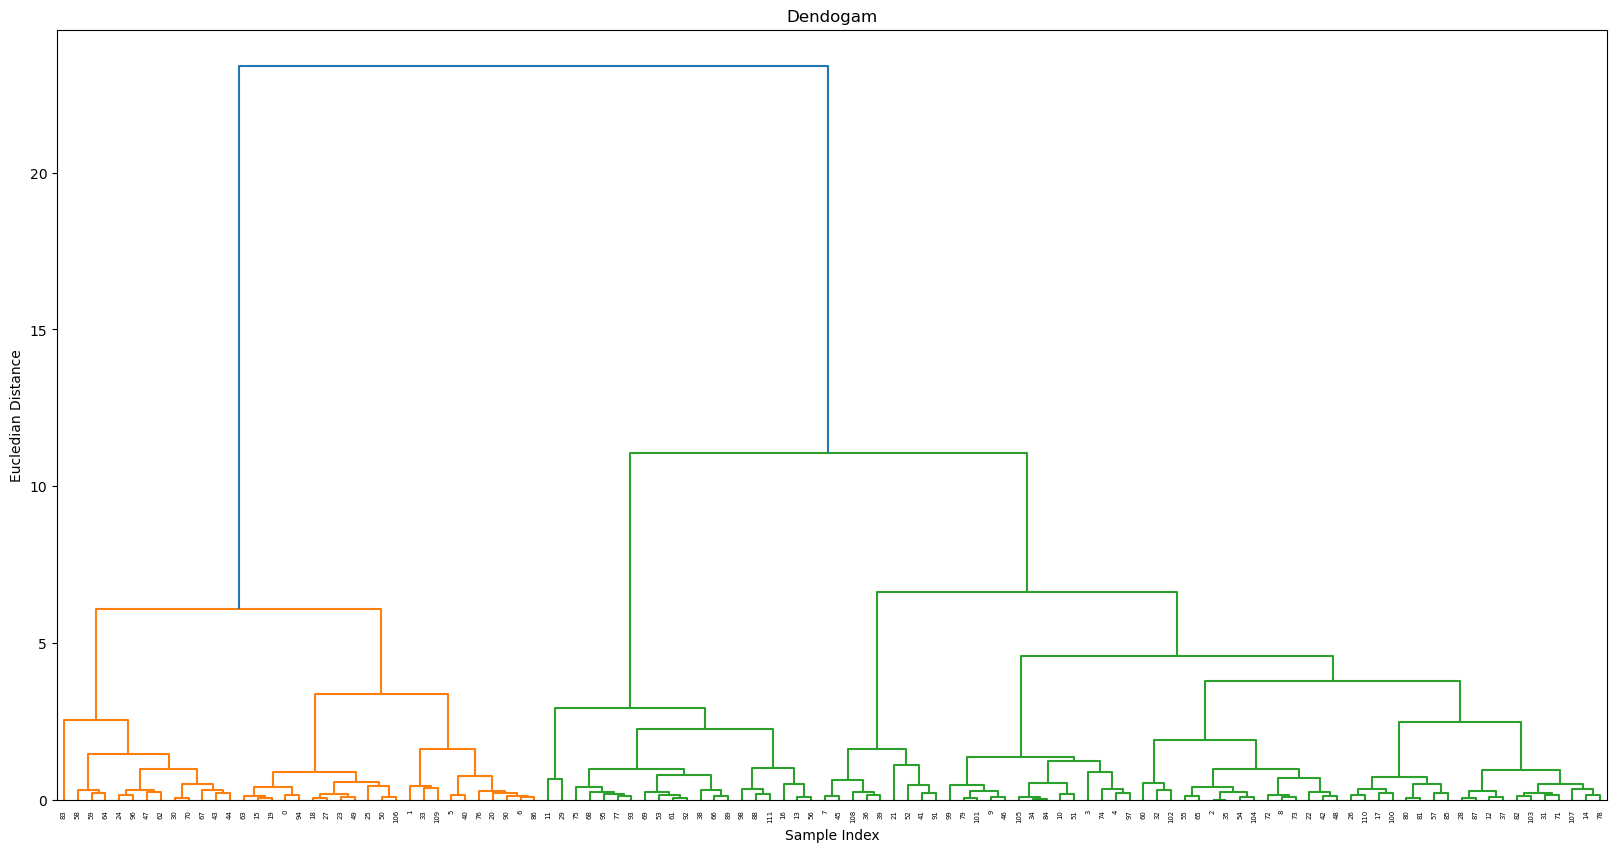

In [23]:
# apply agglomerative clustering
# first construct the dendogram
import scipy.cluster.hierarchy as sc
# plot dendogram
plt.figure(figsize=(20 , 10))
plt.title("Dendograms")

# create dendogram
sc.dendrogram(sc.linkage(x_train_pca_scaled , method='ward'))
plt.title('Dendogam')
plt.xlabel("Sample Index")
plt.ylabel("Eucledian Distance")

In [25]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2 ,metric = 'euclidean' , linkage='ward')
cluster.fit(x_train_pca_scaled)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [26]:
cluster.labels_

array([1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0])

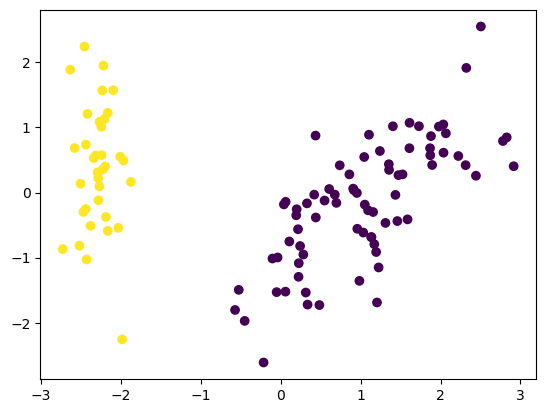

In [27]:
plt.scatter(x_train_pca_scaled[: ,0] , x_train_pca_scaled[: , 1] , c=cluster.labels_)

In [ ]:
# # predict flower type for a new sample
# # AgglomerativeClustering has no direct predict() method,
# # so we map each cluster to the majority flower class in the training data.
# cluster_labels = cluster.labels_
# unique_cluster_ids = np.unique(cluster_labels)

# cluster_to_flower = {}
# for cluster_id in unique_cluster_ids:
#     majority_class = np.bincount(y_train[cluster_labels == cluster_id]).argmax()
#     cluster_to_flower[cluster_id] = df.target_names[majority_class]

# cluster_centers = np.array([
#     x_train_pca_scaled[cluster_labels == cluster_id].mean(axis=0)
#     for cluster_id in unique_cluster_ids
# ])

# new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
# new_flower_scaled = scaler.transform(new_flower)
# new_flower_pca = pca.transform(new_flower_scaled)

# predicted_cluster = unique_cluster_ids[
#     np.argmin(np.linalg.norm(cluster_centers - new_flower_pca, axis=1))
# ]
# predicted_flower = cluster_to_flower[predicted_cluster]

# print("Predicted cluster:", predicted_cluster)
# print("Predicted flower type:", predicted_flower)

Predicted cluster: 1
Predicted flower type: setosa


c:\Users\YASH JAIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
